#Homework 6: CNNs

###Amrit Dhillon

#Importing libraries

In [2]:
!pip install optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.3 MB/s eta 0:00:00


#Importing the data

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train_full.shape)
print("Test data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


#Visualizing the data

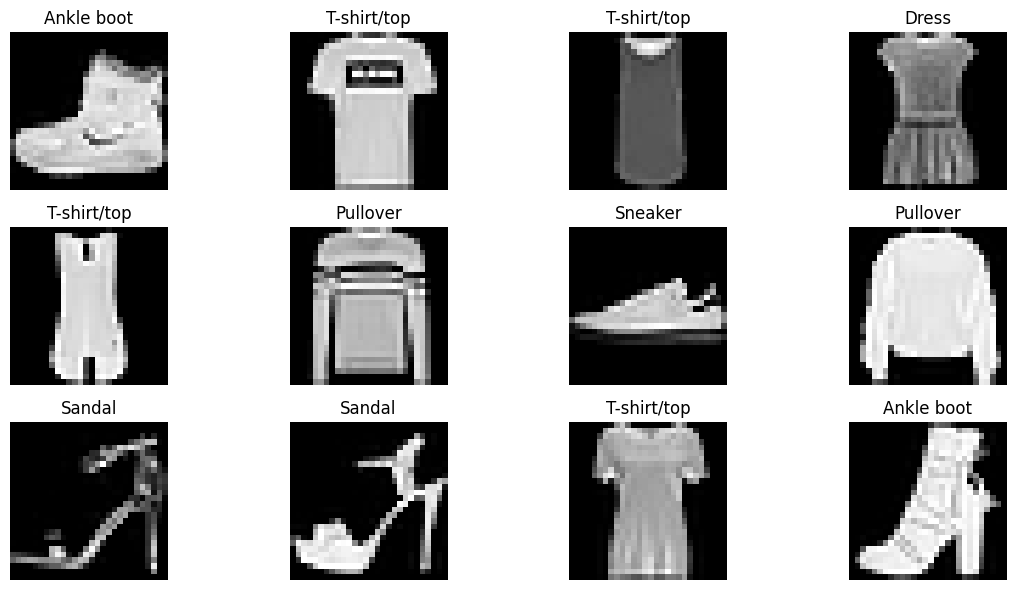

In [4]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

#Preprocessing

In [5]:
#train/validation split from training set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    stratify=y_train_full,
    random_state=42
)

#normalization
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

#add channel dimensions for CNN
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 28, 28, 1)
X_val: (6000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


#Baseline CNN model

In [6]:
#baseline model similar to our in-class CNN style
baseline_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop_base = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_baseline = baseline_cnn.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_base],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8316 - loss: 0.4893 - val_accuracy: 0.8738 - val_loss: 0.3670
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8840 - loss: 0.3291 - val_accuracy: 0.8903 - val_loss: 0.3026
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8987 - loss: 0.2846 - val_accuracy: 0.9018 - val_loss: 0.2727
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9083 - loss: 0.2542 - val_accuracy: 0.9063 - val_loss: 0.2583
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9169 - loss: 0.2312 - val_accuracy: 0.9098 - val_loss: 0.2491
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9239 - loss: 0.2126 - val_accuracy: 0.9105 - val_loss: 0.2424
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9311 - loss: 0.1956 - val_accuracy: 0.9143 - val_loss: 0.2393
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9367 - loss: 0.1802 - val_accuracy: 

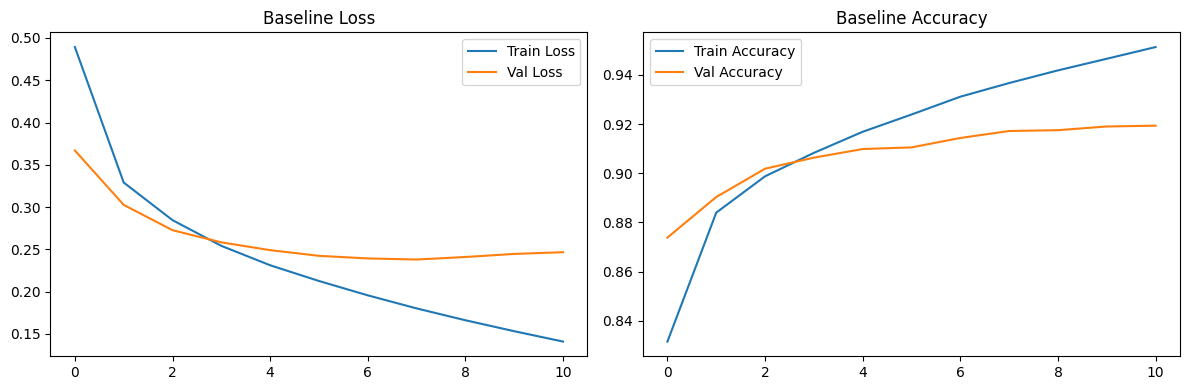

In [8]:
#baseline training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Val Loss")
plt.title("Baseline Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history["accuracy"], label="Train Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Val Accuracy")
plt.title("Baseline Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

#Experiments (changing one factor at a time)

### Experiment 1: more filters only

In [9]:
#changed only Conv2D filters from 32 -> 64
cnn_exp1 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_exp1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_exp1 = cnn_exp1.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8298 - loss: 0.4790 - val_accuracy: 0.8792 - val_loss: 0.3408
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8875 - loss: 0.3176 - val_accuracy: 0.8968 - val_loss: 0.2896
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9014 - loss: 0.2740 - val_accuracy: 0.9035 - val_loss: 0.2681
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9117 - loss: 0.2440 - val_accuracy: 0.9072 - val_loss: 0.2547
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9201 - loss: 0.2201 - val_accuracy: 0.9103 - val_loss: 0.2466
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9278 - loss: 0.2004 - val_accuracy: 0.9127 - val_loss: 0.2452
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9344 - loss: 0.1825 - val_accuracy: 0.9130 - val_loss: 0.2441
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9404 - loss: 0.1665 - val_accuracy: 0.

### Experiment 2: deeper CNN only

In [10]:
#same baseline size style, added second conv block
cnn_exp2 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_exp2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_exp2 = cnn_exp2.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7824 - loss: 0.6005 - val_accuracy: 0.8380 - val_loss: 0.4397
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8600 - loss: 0.3847 - val_accuracy: 0.8725 - val_loss: 0.3543
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8773 - loss: 0.3375 - val_accuracy: 0.8862 - val_loss: 0.3193
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8887 - loss: 0.3064 - val_accuracy: 0.8948 - val_loss: 0.2937
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8976 - loss: 0.2828 - val_accuracy: 0.9020 - val_loss: 0.2768
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9045 - loss: 0.2632 - val_accuracy: 0.9040 - val_loss: 0.2665
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9104 - loss: 0.2466 - val_accuracy: 0.9065 - val_loss: 0.2593
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9155 - loss: 0.2318 - val_accuracy: 0

### Experiment 3: regularization + training setup

In [11]:
#dropout + L2 + lower learning rate
cnn_exp3 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(1e-4)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu", kernel_regularizer=l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn_exp3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_exp3 = cnn_exp3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7933 - loss: 0.6078 - val_accuracy: 0.8787 - val_loss: 0.3821
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8709 - loss: 0.4012 - val_accuracy: 0.8963 - val_loss: 0.3283
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8863 - loss: 0.3554 - val_accuracy: 0.9038 - val_loss: 0.3075
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8957 - loss: 0.3282 - val_accuracy: 0.9125 - val_loss: 0.2843
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9028 - loss: 0.3073 - val_accuracy: 0.9112 - val_loss: 0.2823
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9103 - loss: 0.2909 - val_accuracy: 0.9180 - val_loss: 0.2735
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9144 - loss: 0.2792 - val_accuracy: 0.9200 - val_loss: 0.2657
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9194 - loss: 0.2683 - val_accuracy: 

#Compare baseline and experiments on validation set

In [12]:
def get_val_metrics(model, X_val, y_val, label):
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    return {
        "Model": label,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, average="weighted"),
        "Recall": recall_score(y_val, y_pred, average="weighted"),
        "F1": f1_score(y_val, y_pred, average="weighted")
    }

val_results = []
val_results.append(get_val_metrics(baseline_cnn, X_val, y_val, "Baseline"))
val_results.append(get_val_metrics(cnn_exp1, X_val, y_val, "Exp1_More_Filters"))
val_results.append(get_val_metrics(cnn_exp2, X_val, y_val, "Exp2_Deeper"))
val_results.append(get_val_metrics(cnn_exp3, X_val, y_val, "Exp3_Reg_Dropout"))

val_comparison = pd.DataFrame(val_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(val_comparison)

,Model,Accuracy,Precision,Recall,F1
0,Exp3_Reg_Dropout,0.926000,0.926142,0.926000,0.925921
1,Baseline,0.917167,0.918743,0.917167,0.917600
2,Exp2_Deeper,0.916833,0.918299,0.916833,0.917062
3,Exp1_More_Filters,0.913000,0.914319,0.913000,0.912561


#Systematic tuning with Optuna

In [13]:
#subset for faster tuning
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=30000,
    stratify=y_train,
    random_state=42
)

def objective(trial):
    filters1 = trial.suggest_categorical("filters1", [16, 32, 64])
    use_second = trial.suggest_categorical("use_second", [False, True])
    filters2 = trial.suggest_categorical("filters2", [32, 64, 128])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.4)
    lr = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    l2_strength = trial.suggest_float("l2_strength", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128])

    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(filters1, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(l2_strength)))
    model.add(layers.MaxPooling2D((2, 2)))

    if use_second:
        model.add(layers.Conv2D(filters2, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(l2_strength)))
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu", kernel_regularizer=l2(l2_strength)))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_tune,
        y_tune,
        epochs=12,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
        verbose=0
    )

    return max(history.history["val_accuracy"])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=12)

print("Best val accuracy:", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-28 06:37:50,020] A new study created in memory with name: no-name-b5c779c6-90ac-4ed2-be27-c156e5ff5b73
[I 2026-05-28 06:38:06,909] Trial 0 finished with value: 0.9071666598320007 and parameters: {'filters1': 16, 'use_second': False, 'filters2': 64, 'dense_units': 64, 'dropout_rate': 0.15666525821950106, 'learning_rate': 0.001361323863386773, 'l2_strength': 0.00012743675065182136, 'batch_size': 128}. Best is trial 0 with value: 0.9071666598320007.
[I 2026-05-28 06:38:30,514] Trial 1 finished with value: 0.9071666598320007 and parameters: {'filters1': 16, 'use_second': True, 'filters2': 32, 'dense_units': 128, 'dropout_rate': 0.303622770472273, 'learning_rate': 0.0009156156639301048, 'l2_strength': 1.3329264690971377e-06, 'batch_size': 128}. Best is trial 0 with value: 0.9071666598320007.
[I 2026-05-28 06:38:45,345] Trial 2 finished with value: 0.887499988079071 and parameters: {'filters1': 16, 'use_second': True, 'filters2': 128, 'dense_units': 256, 'dropout_rate': 0.06475376

Best val accuracy: 0.9175000190734863
Best params: {'filters1': 64, 'use_second': False, 'filters2': 32, 'dense_units': 256, 'dropout_rate': 0.1518111050298726, 'learning_rate': 0.0003534855190810051, 'l2_strength': 2.492240228080667e-06, 'batch_size': 128}


#Build final tuned model and train

In [14]:
best = study.best_params

X_train_final = np.concatenate([X_train, X_val], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)

final_cnn = models.Sequential()
final_cnn.add(layers.Input(shape=(28, 28, 1)))
final_cnn.add(layers.Conv2D(best["filters1"], (3, 3), activation="relu", padding="same", kernel_regularizer=l2(best["l2_strength"])))
final_cnn.add(layers.MaxPooling2D((2, 2)))

if best["use_second"]:
    final_cnn.add(layers.Conv2D(best["filters2"], (3, 3), activation="relu", padding="same", kernel_regularizer=l2(best["l2_strength"])))
    final_cnn.add(layers.MaxPooling2D((2, 2)))

final_cnn.add(layers.Flatten())
final_cnn.add(layers.Dense(best["dense_units"], activation="relu", kernel_regularizer=l2(best["l2_strength"])))
if best["dropout_rate"] > 0:
    final_cnn.add(layers.Dropout(best["dropout_rate"]))
final_cnn.add(layers.Dense(10, activation="softmax"))

final_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_final = final_cnn.fit(
    X_train_final,
    y_train_final,
    epochs=20,
    batch_size=best["batch_size"],
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8320 - loss: 0.4881 - val_accuracy: 0.8842 - val_loss: 0.3370
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8851 - loss: 0.3263 - val_accuracy: 0.8995 - val_loss: 0.2855
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9006 - loss: 0.2800 - val_accuracy: 0.9060 - val_loss: 0.2609
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9101 - loss: 0.2512 - val_accuracy: 0.9125 - val_loss: 0.2459
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9176 - loss: 0.2300 - val_accuracy: 0.9155 - val_loss: 0.2365
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9251 - loss: 0.2107 - val_accuracy: 0.9157 - val_loss: 0.2305
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9318 - loss: 0.1947 - val_accuracy: 0.9183 - val_loss: 0.2278
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9364 - loss: 0.1817 - val_accuracy: 0

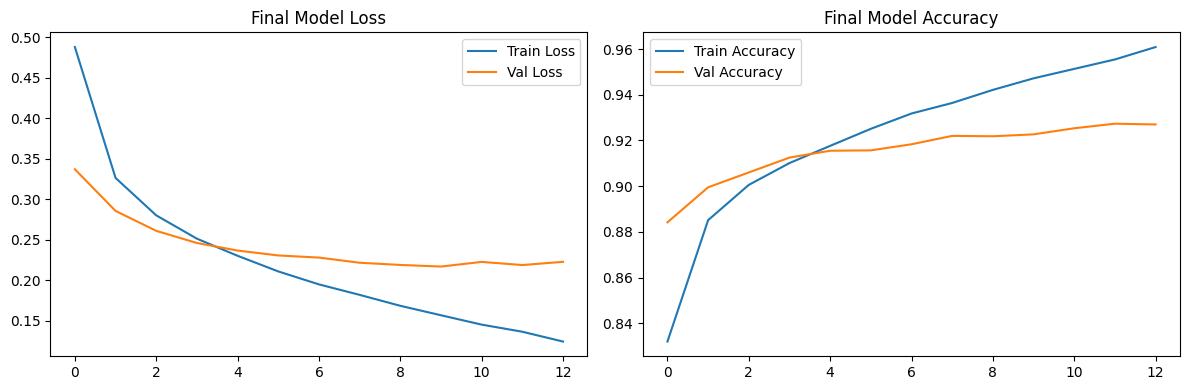

In [15]:
# final training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_final.history["loss"], label="Train Loss")
plt.plot(history_final.history["val_loss"], label="Val Loss")
plt.title("Final Model Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final.history["accuracy"], label="Train Accuracy")
plt.plot(history_final.history["val_accuracy"], label="Val Accuracy")
plt.title("Final Model Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

#Final model test evaluation

In [17]:
y_test_prob = final_cnn.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted")
test_recall = recall_score(y_test, y_test_pred, average="weighted")
test_f1 = f1_score(y_test, y_test_pred, average="weighted")

print("Final Model Test Accuracy:", round(test_acc, 4))
print("Final Model Test Precision:", round(test_precision, 4))
print("Final Model Test Recall:", round(test_recall, 4))
print("Final Model Test F1:", round(test_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

Final Model Test Accuracy: 0.9152
Final Model Test Precision: 0.9159
Final Model Test Recall: 0.9152
Final Model Test F1: 0.9153

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.86      0.87      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.87      0.84      0.86      1000
       Dress       0.88      0.94      0.91      1000
        Coat       0.88      0.85      0.86      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.76      0.78      0.77      1000
     Sneaker       0.94      0.99      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



#Final Model Evaluation on Held-Out Test Set

After selecting my final tuned CNN with Optuna, I evaluated it on the held-out Fashion MNIST test set which had 10,000 images.

- **Test Accuracy:** 0.9152  
- **Test Precision (weighted):** 0.9159  
- **Test Recall (weighted):** 0.9152  
- **Test F1 (weighted):** 0.9153  

These results show that the model generalizes well and stays consistent across multiple evaluation metrics, not just accuracy.

#Training/Validation Behavior and Overfitting

From the training curves, both training and validation performance improved steadily in early epochs. Validation loss improved until around the middle to later epochs, then began to flatten and slightly rise while training accuracy continued to increase.

This pattern indicates there is mild overfitting near the end of training. The model kept fitting the training data better, but validation gains became smaller. I used early stopping with restored best weights to reduce this effect and keep the strongest validation checkpoint.

#What Improved, What Worsened, and Model Tradeoffs

I compared multiple configurations and changed one factor at a time in key experiments.

- The baseline CNN gave a strong starting point with a validation accuracy of around 0.917.
- Increasing filters only like I did in Experiment 1 did not improve performance and resulted in a validation accuracy around 0.913, suggesting extra width alone was not enough.
- Adding a deeper second conv block without other regularization like in Experiment 2 stayed near baseline with a validation accuracy around 0.917.
- Adding regularization + dropout + lower learning rate like in Experiment 3 gave the best validation result of 0.926, which was the clearest improvement before systematic tuning.
- Optuna tuning then found a strong final setup with best validation accuracy around 0.9175 during search and solid final test performance.
- It was evident by a large margin that my weakest class was shirts in terms of precision, recall, and F1-score (0.76, 0.78, 0.77).

The main tradeoff I observed was that stronger models can improve representation power, but they also increase overfitting risk and training time. Regularization and early stopping helped control that tradeoff.

#Personal Workflow for Future CNN Projects

My practical workflow for future CNN classification tasks:

1. Start with a simple baseline CNN and confirm the full pipeline works from one end to the other.
2. Track both training and validation curves from the beginning so I can detect overfitting early.
3. Run controlled experiments that change one factor at a time like I did with filters, depth, then regularization/training setup to isolate cause and effect.
4. Use a systematic tuning method like Optuna after establishing a stable baseline/experiment structure.
5. Select the final model based on validation behavior plus holdout test metrics, not on one metric alone.
6. Check class level performance like I did with the classification report to identify weaker classes even when overall accuracy is strong.

The key lessons I learned from this assignment were that regularization and learning rate choices mattered more than just adding complexity, and careful validation monitoring was essential for balancing performance and generalization.